# Automated Fake Image Generation for Training OCR Models

This code generates random text and draws it on image, which is used to train an OCR model.
Various fonts, font sizes, font colors, spacings, background colors, and tilt angles, as well as the number of words or lines, can be randomized.
Also, the table structure can be inserted to make the model robust in detecting text even in the presence of tables or lines. 

Bomsoo Kim

02/18/2025

# Generate Text

In [1]:
import random

def generate_text(
    #--- a word of characters -----------------------
    # for random generation of word
    characters = list('''0123456789abcdefghijklmnopqrstuvwxyzABCDEFGHIJKLMNOPQRSTUVWXYZ`~!@#$%^&*()_+-={}|[]\:";'<>?,./'''),
    word_range = range(1,12),
    # for the user-defined dictionary of words
    list_words = [],
    list_words_prob = 1.0, # 0 <= list_words_prob <=1
    list_words_cap_types = ['as-is','lower','upper','title'],
    list_words_cap_types_weights = None, # ex) [1,1,1,1]. Note: len(list_words_cap_types) == len(list_words_cap_types_weights)
    #--- a line of words ----------------------------
    num_words_range = range(0,10),
    indent_range = range(0,15), 
    space_range = [1,2,3], 
    space_weights = [3,2,1],
    #--- a passage of lines -------------------------
    num_lines_range = range(1,20),
):
    #--- check --------------------------------------------------------------
    assert 0 <= list_words_prob <= 1, f'Brad error: failed to meet "0 <= list_words_prob <= 1"... Check list_words_prob = {list_words_prob}'
    if len(list_words) == 0 and list_words_prob != 0:
        list_words_prob = 0 # force to set to zero, if there is no word in the list
        # print(f'Brad warning: list_words_prob is set from "{list_words_prob}" to zero, because there is no word in the list: list_words = {list_words}')
    if list_words_cap_types_weights is None:
        list_words_cap_types_weights = [1] * len(list_words_cap_types)
    assert len(list_words_cap_types) == len(list_words_cap_types_weights), f'Brad error: the lengthes must match between list_words_cap_types = {list_words_cap_types} and list_words_cap_types_weights = {list_words_cap_types_weights}'

    #--- main ---------------------------------------------------------------
    lines = []
    num_lines = random.choice(num_lines_range)
    for _ in range(num_lines):
        words = []
        num_words = random.choice(num_words_range)
        for _ in range(num_words):
            gen_type = random.choices(['random generation', 'list of words'], weights=[1-list_words_prob, list_words_prob], k=1)[0]
            if gen_type == 'random generation':
                len_word = random.choice(word_range)
                word = ''.join(random.choices(characters, k=len_word))
            else:
                cap_type = random.choices(list_words_cap_types, weights=list_words_cap_types_weights, k=1)[0]
                if cap_type == 'lower':
                    word = random.choice(list_words).lower()
                elif cap_type == 'upper':
                    word = random.choice(list_words).upper()
                elif cap_type == 'title':
                    word = random.choice(list_words).title()
                else:
                    word = random.choice(list_words)

            words.append(word)

        len_space = random.choices(space_range, weights=space_weights, k=1)[0]
        space = ' '*len_space
        # print(f'len_space = {len_space}')

        len_indent = random.choice(indent_range)
        indent = ' '*len_indent

        line = indent + space.join(words)
        # print(line)

        lines.append(line)

    return lines

if __name__=='__main__':
    list_words = [] # default
    # with open(r'C:\Users\bomso\bomsoo1\python\bradk\bradk\datasets\sample_data\words.txt') as file: # https://github.com/dwyl/english-words?tab=readme-ov-file
    with open(r'./sample_data/words.txt') as file: # https://github.com/dwyl/english-words?tab=readme-ov-file
        list_words = [w.strip() for w in file.read().split('\n') if w.strip()]

    lines = generate_text(
        list_words = list_words, 
        list_words_prob = 0.7, # 0 <= list_words_prob <=1

        # num_words_range = range(1,10),
        # num_lines_range = range(1,2),
        # indent_range = range(0,1),
    )
    text = '\n'.join(lines)
    print(text)

           [ib   OVERFEATURED   apostemate   woe-threatened   s"C{E   E8qBVy1<   ROSANILINE   unselfreliant
           Assertiveness
    consequent  SUT9$VK7ie$  wide-framed  $*/uG.BkjRV  glide-bomb  bishoprics
           H99ql++  Penetral  (DUS/87  make-talk  yu<$  hirse
          aroids outpension
   diaconicum r Id semipurposiveness theatres d% J|;Y
          Discretional  befleaed  CYSTOMATOUS  monographed  JASZ  Hartleyan  windowpeeper
            N0>%f"o"(hr  Poulter  RT:Gr63Ws*D  Rout  pan-turanianism  <Og%{Ul0
          QxL   A{kQ"}[xij   Hagdon
     acrosphacelus  container  J1
        picture
         altercating P&BF UNVEST Hotei Sarcomatous subchief
         recomputation calci cC,p*n nDOj2g=,Un


# Draw Text on Image

w_text0 = 512, h_text0 = 172
w_text = 539.8759775839649, h_text = 230.80273276697528
x0, y0, x1, y1 = (84, 238, 623, 468)


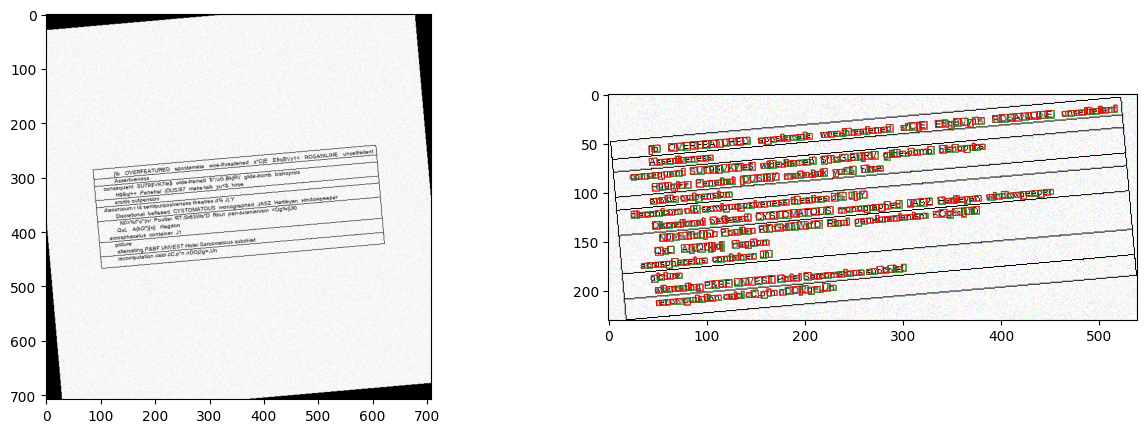

In [2]:
# ref) https://stackoverflow.com/questions/43060479/how-to-get-the-font-pixel-height-using-pils-imagefont-class
# ref) https://stackoverflow.com/questions/64660531/is-there-a-precise-way-to-measure-text-size-in-a-specific-font-in-python-3-7
# ref) https://stackoverflow.com/questions/66274858/choosing-a-pil-imagefont-by-font-name-rather-than-filename-and-cross-platform-f
# ref) https://stackoverflow.com/questions/8753835/how-to-get-a-list-of-all-the-fonts-currently-available-for-matplotlib

from PIL import Image, ImageFont, ImageDraw
import matplotlib.pyplot as plt
import math
import numpy as np

def rotate_vector(x, y, xc, yc, angle=0.0): # https://en.wikipedia.org/wiki/Rotation_matrix
    if angle%360 != 0:
        theta = (-1) * angle * math.pi / 180.0
        x_out = (x-xc)*math.cos(theta) - (y-yc)*math.sin(theta) + xc
        y_out = (x-xc)*math.sin(theta) + (y-yc)*math.cos(theta) + yc
        return [x_out, y_out]
    else:
        return [x, y]

def find_envelope_rectangle(w_text, h_text, angle):
    xc, yc = 0.5*w_text, 0.5*h_text # center point
    xmin, xmax, ymin, ymax = float('inf'), float('-inf'), float('inf'), float('-inf')
    for x, y in [(0,0), (w_text, 0), (0, h_text), (w_text, h_text)]:
        xr, yr = rotate_vector(x, y, xc, yc, angle=angle)
        xmin = min(xmin, xr)
        xmax = max(xmax, xr)
        ymin = min(ymin, yr)
        ymax = max(ymax, yr)
    return xmax - xmin, ymax - ymin

def generate_OCR_image_full(
    lines,
    filepath="arial.ttf", font_size=30, line_spacing=0,
    font_color=(0,0,0), background_color=(255,255,255), background_color_std=(0,0,0),
    angle=0,

    # table parameters
    prob_draw_top_line = 0, # [0, 1]
    prob_draw_bottom_line = 0, # [0, 1]
    prob_draw_left_line = 0, # [0, 1]
    prob_draw_right_line = 0, # [0, 1]
    prob_draw_inner_line_yoffset = 0, # [0, 1]
    table_line_width = 1,
    table_line_color = (0,0,0),
    table_top_line_margin = 5,
    table_bottom_line_margin = 5,
    table_left_line_margin = 5,
    table_right_line_margin = 5,
    table_inner_line_yoffset = 0,
    table_outer_space_margin = 2,
    
    debug = False,
    ):
    #--- table parameter setting ------------------------------------------------
    if (prob_draw_top_line == 0) and (prob_draw_bottom_line == 0) and (prob_draw_left_line == 0) and (prob_draw_right_line == 0) and (prob_draw_inner_line_yoffset == 0):
        table_top_line_margin_ = table_bottom_line_margin_ = table_left_line_margin_ = table_right_line_margin_ = table_inner_line_yoffset_ = table_outer_space_margin_ = 0 # reset to 0
    else:
        table_top_line_margin_ = table_top_line_margin
        table_bottom_line_margin_ = table_bottom_line_margin
        table_left_line_margin_ = table_left_line_margin
        table_right_line_margin_ = table_right_line_margin
        table_inner_line_yoffset_ = table_inner_line_yoffset
        table_outer_space_margin_ = table_outer_space_margin

    #--- font -------------------------------------------------------------------
    font = ImageFont.truetype(filepath, font_size)
    ascent, descent = font.getmetrics()

    #--- get width & heigth of envolope text box without angle ------------------
    w_text0, h_text0 = 0, 0 # initialize
    for line in lines:
        w = 0 # initialize
        for c in line: # read each character of each line
            w += font.getlength(c) # add width of each character

        w_text0 = max(w_text0, w) # find the max width of text
        # h_text0 += font.size + line_spacing
        h_text0 += ascent + descent + line_spacing

    w_text0, h_text0 = int(w_text0), int(h_text0 + descent)

    if debug:
        print(f'w_text0 = {w_text0}, h_text0 = {h_text0}')

    #--- image --------------------------------------------------------
    # s_text = w_text0 + h_text0 # envelop square to ensure there is no black color area within the rectangle (w_text, h_text)
    s_text = w_text0 + h_text0 + (
        max(0, table_top_line_margin_) + 
        max(0, table_bottom_line_margin_) + 
        max(0, table_left_line_margin_) + 
        max(0, table_right_line_margin_) + 
        max(0, 2*table_outer_space_margin_)) # envelop square to ensure there is no black color area within the rectangle (w_text, h_text)

    # img_canvas = Image.new("RGB", (s_text, s_text), background_color) # initialize
    img_canvas = Image.fromarray(np.stack([
        np.random.normal(background_color[0], background_color_std[0], size=(s_text, s_text)).clip(min=0, max=255).round(decimals=0).astype(dtype=np.uint8),
        np.random.normal(background_color[1], background_color_std[1], size=(s_text, s_text)).clip(min=0, max=255).round(decimals=0).astype(dtype=np.uint8),
        np.random.normal(background_color[2], background_color_std[2], size=(s_text, s_text)).clip(min=0, max=255).round(decimals=0).astype(dtype=np.uint8),
    ], axis=-1)) # (H, W, C=3)

    draw = ImageDraw.Draw(img_canvas)

    x_table0, y_table0 = 0.5*(s_text - w_text0) - table_left_line_margin_, 0.5*(s_text - h_text0) - table_top_line_margin_
    x_table1, y_table1 = 0.5*(s_text + w_text0) + table_right_line_margin_, 0.5*(s_text + h_text0) + table_bottom_line_margin_

    x0, y_ = 0.5*(s_text - w_text0), 0.5*(s_text - h_text0)
    paragraph = []
    for i, line in enumerate(lines):
        #--- draw text ---------------------------------------
        draw.text((x0, y_), line, font=font, fill=font_color)

        #--- bbox --------------------------------------------
        x_ = x0
        words, word_ = [], {}
        for c in line:
            bbox = draw.textbbox((x_, y_), c, font=font) # cf) font.getbbox(c)
            x_ += draw.textlength(c, font=font) # cf) font.getlength(c)

            #--- save/draw bboxes ----------------------------
            if bbox[1] == bbox[3]: # zero height, i.e. space
                if word_:
                    word_['word'] = ''.join(word_['word']) # concat characters to form a word
                    words.append(word_)

                    word_ = {} # initialize
            else:
                if 'word' not in word_:
                    word_['word'] = [] # initialize
                    word_['bboxes'] = [] # initialize
                word_['word'].append(c)
                word_['bboxes'].append(bbox)

        if word_:
            word_['word'] = ''.join(word_['word']) # concat characters to form a word
            words.append(word_)

        paragraph.append(words)

        # y_ += font.size + line_spacing
        y_ += ascent + descent + line_spacing

        if (i < len(lines)-1) and random.choices(population=[False, True], weights=[1-prob_draw_inner_line_yoffset, prob_draw_inner_line_yoffset], k=1)[0]: # draw table lines
            draw.line([
                (x_table0, y_ - 0.5*line_spacing + table_inner_line_yoffset_), 
                (x_table1, y_ - 0.5*line_spacing + table_inner_line_yoffset_)], fill=table_line_color, width=table_line_width)

    if random.choices(population=[False, True], weights=[1-prob_draw_top_line, prob_draw_top_line], k=1)[0]:
        draw.line([(x_table0, y_table0), (x_table1, y_table0)], fill=table_line_color, width=table_line_width)
    if random.choices(population=[False, True], weights=[1-prob_draw_right_line, prob_draw_right_line], k=1)[0]:
        draw.line([(x_table1, y_table0), (x_table1, y_table1)], fill=table_line_color, width=table_line_width)
    if random.choices(population=[False, True], weights=[1-prob_draw_bottom_line, prob_draw_bottom_line], k=1)[0]:
        draw.line([(x_table1, y_table1), (x_table0, y_table1)], fill=table_line_color, width=table_line_width)
    if random.choices(population=[False, True], weights=[1-prob_draw_left_line, prob_draw_left_line], k=1)[0]:
        draw.line([(x_table0, y_table1), (x_table0, y_table0)], fill=table_line_color, width=table_line_width)


    #--- rotated image -----------------------------------------------
    img_rotate = img_canvas.rotate(angle=angle, expand=False)

    # w_text, h_text = find_envelope_rectangle(w_text0, h_text0, angle)
    w_text, h_text = find_envelope_rectangle(w_text0 + max(0, table_left_line_margin_) + max(0, table_right_line_margin_), h_text0 + max(0, table_top_line_margin_) + max(0, table_bottom_line_margin_), angle)
    w_text, h_text = w_text + 2*table_outer_space_margin_, h_text + 2*table_outer_space_margin_ # add margin
    if debug:
        print(f'w_text = {w_text}, h_text = {h_text}')

    xc, yc = 0.5*s_text, 0.5*s_text
    x_off, y_off = 0.5*(s_text - w_text), 0.5*(s_text - h_text)

    p_rotated = []
    for l in paragraph:
        l_rotated = []
        for w in l:
            w_rotated = {'word':[], 'rboxes':[], 'bboxes':[]} # initialize

            for c, (x_min0, y_min0, x_max0, y_max0) in zip(w['word'], w['bboxes']):
                rbox_ = []
                x_min, y_min, x_max, y_max = float('inf'), float('inf'), float('-inf'), float('-inf')
                for x_, y_ in [ # clock-wise direction
                    (x_min0, y_min0), # top left
                    (x_max0, y_min0), # top right
                    (x_max0, y_max0), # bottom right
                    (x_min0, y_max0), # bottom left
                    ]:
                    xr, yr = rotate_vector(x_, y_, xc, yc, angle=angle)
                    rbox_.append([xr, yr])
                    x_min = min(x_min, xr)
                    y_min = min(y_min, yr)
                    x_max = max(x_max, xr)
                    y_max = max(y_max, yr)

                w_rotated['word'].append(c)
                w_rotated['rboxes'].append([[x_-x_off, y_-y_off] for x_, y_ in rbox_])
                w_rotated['bboxes'].append([x_min-x_off, y_min-y_off, x_max-x_off, y_max-y_off])
            w_rotated['word'] = ''.join(w_rotated['word'])
            l_rotated.append(w_rotated)
        p_rotated.append(l_rotated)
    #----------------------------------------------------------------------
    # x0, y0 = 0.5*(s_text - w_text), 0.5*(s_text - h_text)
    # x1, y1 = x0 + w_text, y0 + h_text
    x0, y0 = int(0.5*(s_text - w_text)), int(0.5*(s_text - h_text))
    x1, y1 = int(x0 + w_text), int(y0 + h_text)
    img_crop = img_rotate.crop((x0, y0, x1, y1))
    if debug:
        print(f'x0, y0, x1, y1 = {x0, y0, x1, y1}')

    return {'img_canvas':img_canvas, 'img_rotate':img_rotate, 'img_crop':img_crop, 'paragraph_rotated':p_rotated}

if __name__=='__main__':
    import matplotlib.patches as patches

    out = generate_OCR_image_full(
        lines,
        filepath="arial.ttf", font_size=10, line_spacing=0,
        font_color=(0,0,0), background_color=(255,255,255), background_color_std=(20,20,20),
        angle=5,

        # table parameters
        prob_draw_top_line = 1, # [0, 1]
        prob_draw_bottom_line = 1, # [0, 1]
        prob_draw_left_line = 1, # [0, 1]
        prob_draw_right_line = 1, # [0, 1]
        prob_draw_inner_line_yoffset = 0.5, # [0, 1]
        table_line_width = 1,
        table_line_color = (0,0,0),
        table_top_line_margin = 5,
        table_bottom_line_margin = 5,
        table_left_line_margin = 5,
        table_right_line_margin = 5,
        table_inner_line_yoffset = 0,
        table_outer_space_margin = 2,

        # debug = False,
        debug = True,
        )

    img_canvas, img_rotate, img_crop, paragraph_rotated = out['img_canvas'], out['img_rotate'], out['img_crop'], out['paragraph_rotated']

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15,5))
    ax1.imshow(img_rotate)
    ax2.imshow(img_crop)
    for l in paragraph_rotated:
        for w in l:
            # print(w)
            for x0_,y0_,x1_,y1_ in w['bboxes']:
                ax2.add_patch(patches.Rectangle((x0_,y0_), x1_-x0_, y1_-y0_, fill=False, edgecolor='green', linewidth=0.5))
            for xys in w['rboxes']:
                ax2.add_patch(patches.Polygon(xys, closed=True, fill=False, edgecolor='red', linewidth=0.5))
    plt.show()

{'word': 'My', 'bboxes': [[0.0, 3.0, 8.0, 10.0], [8.0, 5.0, 13.0, 12.0]]}
{'word': 'name', 'bboxes': [[16.0, 5.0, 22.0, 10.0], [22.0, 5.0, 28.0, 10.0], [28.0, 5.0, 36.0, 10.0], [36.0, 5.0, 42.0, 10.0]]}
{'word': 'is', 'bboxes': [[45.0, 3.0, 47.0, 10.0], [47.0, 5.0, 52.0, 10.0]]}
{'word': 'Bom-soo;', 'bboxes': [[55.0, 3.0, 62.0, 10.0], [62.0, 5.0, 68.0, 10.0], [68.0, 5.0, 76.0, 10.0], [76.0, 7.0, 80.0, 10.0], [79.0, 5.0, 84.0, 10.0], [84.0, 5.0, 90.0, 10.0], [90.0, 5.0, 96.0, 10.0], [96.0, 5.0, 99.0, 11.0]]}
{'word': 'a', 'bboxes': [[18.0, 18.0, 24.0, 23.0]]}
{'word': 'also', 'bboxes': [[0.0, 31.0, 6.0, 36.0], [6.0, 29.0, 8.0, 36.0], [8.0, 31.0, 13.0, 36.0], [13.0, 31.0, 19.0, 36.0]]}
{'word': '"Brad', 'bboxes': [[22.0, 29.0, 26.0, 36.0], [26.0, 29.0, 33.0, 36.0], [33.0, 31.0, 37.0, 36.0], [36.0, 31.0, 42.0, 36.0], [42.0, 29.0, 48.0, 36.0]]}
{'word': 'KIM"', 'bboxes': [[51.0, 29.0, 58.0, 36.0], [58.0, 29.0, 61.0, 36.0], [61.0, 29.0, 69.0, 36.0], [69.0, 29.0, 73.0, 36.0]]}
{'word': 'Hell

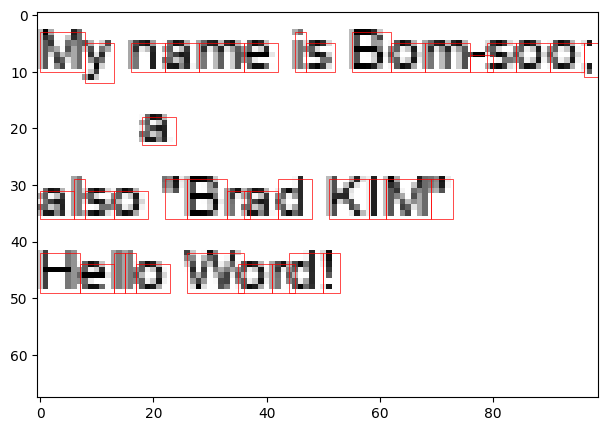

In [3]:
from PIL import Image, ImageDraw, ImageFont
import matplotlib.pyplot as plt

def generate_OCR_image(
    lines,
    img_size_xy=None, min_img_size_xy=None, # ex) min_img_size_xy=(16,16)
    xy = (0, 0), 
    overlap_ratio_threshold=0.7, draw_bboxes=False, # unused, old parameters
    background_color=(255,255,255), background_color_std=(0,0,0),
    **kwarg,
    ):

    out = generate_OCR_image_full(lines, background_color=background_color, background_color_std=background_color_std, **kwarg)

    if img_size_xy is None:
        w_img, h_img = out['img_crop'].size
        w_img += xy[0]
        h_img += xy[1]
    else:
        w_img, h_img = img_size_xy

    if min_img_size_xy is not None:
        min_w, min_h = min_img_size_xy
        w_img, h_img = max(w_img, min_w), max(h_img, min_h)

    img = Image.fromarray(np.stack([
        np.random.normal(background_color[0], background_color_std[0], size=(h_img, w_img)).clip(min=0, max=255).round(decimals=0).astype(dtype=np.uint8),
        np.random.normal(background_color[1], background_color_std[1], size=(h_img, w_img)).clip(min=0, max=255).round(decimals=0).astype(dtype=np.uint8),
        np.random.normal(background_color[2], background_color_std[2], size=(h_img, w_img)).clip(min=0, max=255).round(decimals=0).astype(dtype=np.uint8),
    ], axis=-1)) # (H, W, C=3)

    Image.Image.paste(img, out['img_crop'], xy)

    #--- coordinates -------------------------------------------------
    paragraph = []
    x_off, y_off = xy
    for l in out['paragraph_rotated']:
        line = []
        for w in l:
            word = {'word':[], 'bboxes':[]}
            for c, (xmin0,ymin0,xmax0,ymax0) in zip(w['word'], w['bboxes']):
                xmin = xmin0 + x_off
                ymin = ymin0 + y_off
                xmax = xmax0 + x_off
                ymax = ymax0 + y_off
                if (0 <= 0.5*(xmin + xmax) < w_img) and (0 <= 0.5*(ymin + ymax) < h_img):
                    word['word'].append(c)
                    word['bboxes'].append([xmin,ymin,xmax,ymax])

            if word['word']:
                word['word'] = ''.join(word['word'])
                line.append(word)
        if line:
            paragraph.append(line)

    return img, paragraph


if __name__=='__main__':
    import matplotlib.patches as patches
# for i, row in list_fonts.iterrows():
#     filepath, font_name = row['filepath'], row['font_name']
#     print(font_name)
    
    lines = [
        'My name is Bom-soo;',
        '      a',
        'also "Brad KIM"',
        'Hello Word!',
        ''
    ]

    img_size_xy = None
    # img_size_xy = (190,48)
    # img_size_xy = (600,600)

    img, paragraph = generate_OCR_image(
        lines,
        # font_size=30, line_spacing=0, img_size_xy=img_size_xy,
        font_size=10, line_spacing=0, img_size_xy=img_size_xy,
        xy=(0, 0), filepath="arial.ttf", draw_bboxes=False,
        # xy=(0, 0), filepath=r"C:\Windows\Fonts\msgothic.ttc", draw_bboxes=False,

        # prob_draw_top_line = 1, # [0, 1]
        # prob_draw_bottom_line = 1, # [0, 1]
        # prob_draw_left_line = 1, # [0, 1]
        # prob_draw_right_line = 1, # [0, 1]
        # prob_draw_inner_line_yoffset = 0.5, # [0, 1]
        # table_line_width = 1,
        # table_line_color = (0,0,0),
        # table_top_line_margin = 5,
        # table_bottom_line_margin = 5,
        # table_left_line_margin = 5,
        # table_right_line_margin = 5,
        # table_inner_line_yoffset = 0,
        # table_outer_space_margin = 2,        
        )

    fig, (ax1) = plt.subplots(1, 1, figsize=(15,5))
    ax1.imshow(img)
    for l in paragraph:
        for w in l:
            print(w)
            for x0_,y0_,x1_,y1_ in w['bboxes']:
                ax1.add_patch(patches.Rectangle((x0_,y0_), x1_-x0_, y1_-y0_, fill=False, edgecolor='red', linewidth=0.5))
            # for xys in w['rboxes']:
            #     ax1.add_patch(patches.Polygon(xys, closed=True, fill=False, edgecolor='red', linewidth=0.5))
    plt.show()

# Generate Random Sample

font_color = (93, 55, 118)
background_color = (197, 159, 148)


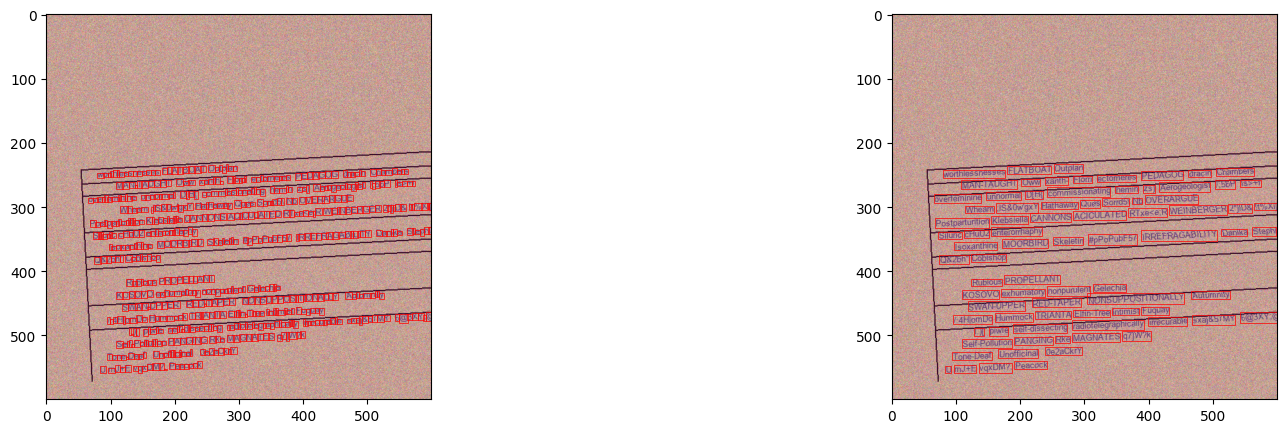

In [4]:
import random

def generate_random_sample(
    # generate_text
    characters = list('''0123456789abcdefghijklmnopqrstuvwxyzABCDEFGHIJKLMNOPQRSTUVWXYZ`~!@#$%^&*()_+-={}|[]\:";'<>?,./'''),
    word_range = range(1,12),
    list_words = [],
    list_words_prob = 1.0, # 0 <= list_words_prob <=1
    list_words_cap_types = ['as-is','lower','upper','title'],
    list_words_cap_types_weights = None, # ex) [1,1,1,1]. Note: len(list_words_cap_types) == len(list_words_cap_types_weights)
    space_range = [1,2,3],
    space_weights = [3,2,1],
    num_words_range = range(0,10),
    num_lines_range = range(1,20),     
    indent_range = range(0,15), 

    # generate_OCR_image
    font_size_range = range(10, 50),
    font_size_weights = None, # [5,4,3,2,1]
    line_spacing_range = range(0, 5),
    orig_point_max_ratio_range = 0.5,
    font_color_max_range = 120,
    background_color_max_range = 120,
    background_color_std=(0,0,0),
    angle_range=range(0,1),
    filepath="arial.ttf",
    img_size_xy = (600, 600),
    min_img_size_xy=(16, 16),
    overlap_ratio_threshold=0.7, draw_bboxes=False,
    debug=False,

    # table parameters
    prob_draw_top_line = 0, # [0, 1]
    prob_draw_bottom_line = 0, # [0, 1]
    prob_draw_left_line = 0, # [0, 1]
    prob_draw_right_line = 0, # [0, 1]
    prob_draw_inner_line_yoffset = 0, # [0, 1]
    table_line_width_range = range(1,2),
    table_line_color_max_range = 120,
    table_top_line_margin_range = range(1,6),
    table_bottom_line_margin_range = range(1,6),
    table_left_line_margin_range = range(1,6),
    table_right_line_margin_range = range(1,6),
    table_inner_line_yoffset_range = range(0,1),
    table_outer_space_margin = 2,
    ):

    lines = generate_text(characters=characters, word_range=word_range, list_words=list_words, list_words_prob=list_words_prob, list_words_cap_types=list_words_cap_types, list_words_cap_types_weights=list_words_cap_types_weights, space_range=space_range, space_weights=space_weights, num_words_range=num_words_range, num_lines_range=num_lines_range, indent_range=indent_range,)

    # font_size = random.choice(font_size_range)
    font_size = random.choices(font_size_range, weights=font_size_weights, k=1)[0]
    line_spacing=random.choice(line_spacing_range)
    xy = (
        int(random.uniform(0, orig_point_max_ratio_range) * (img_size_xy[0] if img_size_xy is not None else 0)), 
        int(random.uniform(0, orig_point_max_ratio_range) * (img_size_xy[1] if img_size_xy is not None else 0)))
    font_color = (
        random.choice(range(0, font_color_max_range)),
        random.choice(range(0, font_color_max_range)),
        random.choice(range(0, font_color_max_range)))
    background_color = (
        255 - random.choice(range(0, background_color_max_range)),
        255 - random.choice(range(0, background_color_max_range)),
        255 - random.choice(range(0, background_color_max_range)))
    angle = random.choice(angle_range)
    table_line_width = random.choice(table_line_width_range)
    table_line_color = (
        random.choice(range(0, table_line_color_max_range)),
        random.choice(range(0, table_line_color_max_range)),
        random.choice(range(0, table_line_color_max_range)))
    table_top_line_margin = random.choice(table_top_line_margin_range)
    table_bottom_line_margin = random.choice(table_bottom_line_margin_range)
    table_left_line_margin = random.choice(table_left_line_margin_range)
    table_right_line_margin = random.choice(table_right_line_margin_range)
    table_inner_line_yoffset = random.choice(table_inner_line_yoffset_range)

    if debug:
        print(f'font_color = {font_color}')
        print(f'background_color = {background_color}')

    img, paragraph = generate_OCR_image(
        lines, 
        img_size_xy=img_size_xy, min_img_size_xy=min_img_size_xy, xy=xy, 
        filepath=filepath, font_size=font_size, line_spacing=line_spacing, 
        draw_bboxes=draw_bboxes, 
        font_color=font_color, background_color=background_color, background_color_std=background_color_std, angle=angle,
        overlap_ratio_threshold=overlap_ratio_threshold,
        prob_draw_top_line = prob_draw_top_line,
        prob_draw_bottom_line = prob_draw_bottom_line,
        prob_draw_left_line = prob_draw_left_line,
        prob_draw_right_line = prob_draw_right_line,
        prob_draw_inner_line_yoffset = prob_draw_inner_line_yoffset,
        table_line_width = table_line_width,
        table_line_color = table_line_color,
        table_top_line_margin = table_top_line_margin,
        table_bottom_line_margin = table_bottom_line_margin,
        table_left_line_margin = table_left_line_margin,
        table_right_line_margin = table_right_line_margin,
        table_inner_line_yoffset = table_inner_line_yoffset,
        table_outer_space_margin = table_outer_space_margin,        
        )

    labels_char, bboxes_char = [], []
    labels_word, bboxes_word = [], []
    for l in paragraph:
        for w in l:
            xmin, ymin, xmax, ymax = float('inf'), float('inf'), float('-inf'), float('-inf')
            for c, (xmin_, ymin_, xmax_, ymax_) in zip(w['word'], w['bboxes']):
                if c == ' ':
                    raise(Exception(f'Brad error: a space character is detected with non-zero bbox area: font_size = {font_size}; filepath = {filepath}'))

                labels_char.append(c)
                bboxes_char.append([xmin_, ymin_, xmax_, ymax_])

                xmin = min(xmin, xmin_)
                ymin = min(ymin, ymin_)
                xmax = max(xmax, xmax_)
                ymax = max(ymax, ymax_)
            
            labels_word.append(w['word'])
            bboxes_word.append([xmin, ymin, xmax, ymax])

    return {
        'image':img,
        'labels_char':labels_char,
        'bboxes_char':bboxes_char,
        'labels_word':labels_word,
        'bboxes_word':bboxes_word,
        'paragraphs':[paragraph], # for future generalization, which can include more than one paragraph
    }

if __name__=='__main__':
    list_words = [] # default
    # with open(r'C:\Users\bomso\bomsoo1\python\bradk\bradk\datasets\sample_data\words.txt') as file: # https://github.com/dwyl/english-words?tab=readme-ov-file
    with open(r'./sample_data/words.txt') as file: # https://github.com/dwyl/english-words?tab=readme-ov-file
        list_words = [w.strip() for w in file.read().split('\n') if w.strip()]
    
    s = generate_random_sample(
        # generate_text
        characters = list('''0123456789abcdefghijklmnopqrstuvwxyzABCDEFGHIJKLMNOPQRSTUVWXYZ`~!@#$%^&*()_+-={}|[]\:";'<>?,./'''),
        word_range = range(1,12),
        list_words = list_words,
        list_words_prob = 0.7, # 0 <= list_words_prob <=1
        list_words_cap_types = ['as-is','lower','upper','title'],
        list_words_cap_types_weights = None, # ex) [1,1,1,1]. Note: len(list_words_cap_types) == len(list_words_cap_types_weights)
        space_range = [1,2,3],
        space_weights = [3,2,1],
        num_words_range = range(0,10),
        # num_words_range = range(1,2), # CHARACTER APPLICATION
        num_lines_range = range(1,20),     
        # num_lines_range = range(1,2), # CHARACTER APPLICATION  
        indent_range = range(0,15), 
        # indent_range = range(0,1), # CHARACTER APPLICATION

        # generate_OCR_image
        # font_size_range = range(10, 50),
        font_size_range = range(10, 80),
        font_size_weights = None,
        line_spacing_range = range(0, 5),
        orig_point_max_ratio_range = 0.5,
        font_color_max_range = 120,
        background_color_max_range = 120,
        background_color_std=(20,20,20),
        angle_range=range(-5,6),        
        filepath="arial.ttf",
        img_size_xy = (600, 600),
        # img_size_xy = None, # CHARACTER APPLICATION
        overlap_ratio_threshold=0.7, draw_bboxes=False,

        # table parameters
        prob_draw_top_line = 0.3, # [0, 1]
        prob_draw_bottom_line = 0.3, # [0, 1]
        prob_draw_left_line = 0.3, # [0, 1]
        prob_draw_right_line = 0.3, # [0, 1]
        prob_draw_inner_line_yoffset = 0.3, # [0, 1]
        table_line_width_range = range(1,4),
        table_line_color_max_range = 120,
        table_top_line_margin_range = range(1,6),
        table_bottom_line_margin_range = range(1,6),
        table_left_line_margin_range = range(1,6),
        table_right_line_margin_range = range(1,6),
        table_inner_line_yoffset_range = range(-3,4),
        table_outer_space_margin = 2,
        
        # debug=False,
        debug=True,
    )

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20,5))
    ax1.imshow(s['image'])
    for x0_,y0_,x1_,y1_ in s['bboxes_char']:
        ax1.add_patch(patches.Rectangle((x0_,y0_), x1_-x0_, y1_-y0_, fill=False, edgecolor='red', linewidth=0.5))
    ax2.imshow(s['image'])
    for x0_,y0_,x1_,y1_ in s['bboxes_word']:
        ax2.add_patch(patches.Rectangle((x0_,y0_), x1_-x0_, y1_-y0_, fill=False, edgecolor='red', linewidth=0.5))
    plt.show()

# Research: all possible fonts

In [5]:
# if __name__=='__main__':
#     import matplotlib.font_manager
#     import pandas as pd

#     #----------------------------------------------------------
#     data = []

#     # ref) https://matplotlib.org/stable/api/font_manager_api.html#matplotlib.font_manager.FontProperties
#     styles = ['normal','italic','oblique']
#     variants = ['normal','small-caps']
#     weights = ['normal','ultralight','light','regular','book','medium','roman','semibold','demibold','demi','bold','heavy','extra bold','black']

#     #----------------------------------------------------------
#     font_names = matplotlib.font_manager.get_font_names()
#     for i, font_name in enumerate(font_names):
#         print(f'[{i+1}/{len(font_names)}] {font_name}')
#         for style in styles:
#             for variant in variants:
#                 for weight in weights:
#                     font = matplotlib.font_manager.FontProperties(family=font_name, style=style, variant=variant, weight=weight)
#                     filepath = matplotlib.font_manager.findfont(font)

#                     data.append({
#                         'font_name':font_name,
#                         'style':style,
#                         'variant':variant,
#                         'weight':weight,
#                         'filepath':filepath,                    
#                     })

#     #----------------------------------------------------------
#     filepaths = matplotlib.font_manager.findSystemFonts()
#     for filepath in filepaths:
#         font = matplotlib.font_manager.get_font(filepath)

#         data.append({
#             'font_name':font.family_name,
#             'filepath':filepath,
#         })

#     #----------------------------------------------------------
#     list_fonts = pd.DataFrame(data)
#     list_fonts = list_fonts.drop_duplicates(subset='filepath', keep='first')
#     # list_fonts.to_excel('advanced_texts.xlsx', index=False)

- choose valid fonts

In [6]:
# if __name__=='__main__':
#     exclude = set([f.strip() for f in r"""
#         C:\Users\bomso\AppData\Local\Programs\Python\Python310\Lib\site-packages\matplotlib\mpl-data\fonts\ttf\STIXSizOneSymBol.ttf
#         C:\Users\bomso\AppData\Local\Programs\Python\Python310\Lib\site-packages\matplotlib\mpl-data\fonts\ttf\STIXSizOneSymReg.ttf
#         C:\Users\bomso\AppData\Local\Programs\Python\Python310\Lib\site-packages\matplotlib\mpl-data\fonts\ttf\STIXSizTwoSymBol.ttf
#         C:\Users\bomso\AppData\Local\Programs\Python\Python310\Lib\site-packages\matplotlib\mpl-data\fonts\ttf\STIXSizTwoSymReg.ttf
#         C:\Windows\Fonts\webdings.ttf
#         C:\Windows\Fonts\segmdl2.ttf
#         C:\Users\bomso\AppData\Local\Programs\Python\Python310\Lib\site-packages\matplotlib\mpl-data\fonts\ttf\STIXNonUniBolIta.ttf
#         C:\Users\bomso\AppData\Local\Programs\Python\Python310\Lib\site-packages\matplotlib\mpl-data\fonts\ttf\STIXNonUniIta.ttf
#         C:\Users\bomso\AppData\Local\Programs\Python\Python310\Lib\site-packages\matplotlib\mpl-data\fonts\ttf\STIXNonUniBol.ttf
#         C:\Users\bomso\AppData\Local\Programs\Python\Python310\Lib\site-packages\matplotlib\mpl-data\fonts\ttf\STIXNonUni.ttf
#         C:\Users\bomso\AppData\Local\Programs\Python\Python310\Lib\site-packages\matplotlib\mpl-data\fonts\ttf\DejaVuSansDisplay.ttf
#         C:\Users\bomso\AppData\Local\Programs\Python\Python310\Lib\site-packages\matplotlib\mpl-data\fonts\ttf\STIXSizFourSymBol.ttf
#         C:\Users\bomso\AppData\Local\Programs\Python\Python310\Lib\site-packages\matplotlib\mpl-data\fonts\ttf\STIXSizFourSymReg.ttf
#         C:\Windows\Fonts\MTEXTRA.TTF
#         C:\Windows\Fonts\symbol.ttf
#         C:\Windows\Fonts\OUTLOOK.TTF
#         C:\Users\bomso\AppData\Local\Programs\Python\Python310\Lib\site-packages\matplotlib\mpl-data\fonts\ttf\cmsy10.ttf
#         C:\Users\bomso\AppData\Local\Programs\Python\Python310\Lib\site-packages\matplotlib\mpl-data\fonts\ttf\DejaVuSerifDisplay.ttf
#         C:\Users\bomso\AppData\Local\Programs\Python\Python310\Lib\site-packages\matplotlib\mpl-data\fonts\ttf\STIXSizFiveSymReg.ttf
#         C:\Windows\Fonts\WINGDNG3.TTF
#         C:\Windows\Fonts\wingding.ttf
#         C:\Windows\Fonts\holomdl2.ttf
#         C:\Windows\Fonts\SansSerifCollection.ttf
#         C:\Users\bomso\AppData\Local\Programs\Python\Python310\Lib\site-packages\matplotlib\mpl-data\fonts\ttf\cmex10.ttf
#         C:\Users\bomso\AppData\Local\Programs\Python\Python310\Lib\site-packages\matplotlib\mpl-data\fonts\ttf\STIXSizThreeSymBol.ttf
#         C:\Users\bomso\AppData\Local\Programs\Python\Python310\Lib\site-packages\matplotlib\mpl-data\fonts\ttf\STIXSizThreeSymReg.ttf
#         C:\Windows\Fonts\REFSPCL.TTF
#         C:\Windows\Fonts\BSSYM7.TTF
#         C:\Windows\Fonts\SegoeIcons.ttf
#         C:\Windows\Fonts\WINGDNG2.TTF
                        
#         C:\Windows\Fonts\PALSCRI.TTF
#         C:\Users\bomso\AppData\Local\Programs\Python\Python310\Lib\site-packages\matplotlib\mpl-data\fonts\ttf\cmmi10.ttf
#         C:\Windows\Fonts\FREESCPT.TTF
#         C:\Windows\Fonts\KUNSTLER.TTF
#         C:\Windows\Fonts\NIAGSOL.TTF
#         C:\Windows\Fonts\BOD_PSTC.TTF
#         C:\Windows\Fonts\GLSNECB.TTF
#         C:\Windows\Fonts\ONYX.TTF
#         C:\Windows\Fonts\PARCHM.TTF
#         C:\Windows\Fonts\NIAGENG.TTF
#         C:\Windows\Fonts\GIGI.TTF
#         C:\Windows\Fonts\RAGE.TTF
#         C:\Windows\Fonts\FRSCRIPT.TTF
#         C:\Windows\Fonts\ITCEDSCR.TTF
#         C:\Windows\Fonts\PLAYBILL.TTF
#         C:\Windows\Fonts\VLADIMIR.TTF
#         C:\Windows\Fonts\BRUSHSCI.TTF
#         C:\Windows\Fonts\GILC____.TTF
#         C:\Windows\Fonts\ITCBLKAD.TTF
#         C:\Windows\Fonts\CALIFI.TTF
#         C:\Windows\Fonts\CHILLER.TTF
#         C:\Windows\Fonts\himalaya.ttf
#         C:\Windows\Fonts\BOD_CR.TTF
#         C:\Windows\Fonts\BOD_CI.TTF
#         """.split('\n') if f.strip()])

#     assert all(f in list_fonts['filepath'].tolist() for f in exclude)

#     list_fonts_valid = [f for f in list_fonts['filepath'].tolist() if f not in exclude]

#     print(f"len(list_fonts['filepath']) = {len(list_fonts['filepath'])}")
#     print(f"len(exclude) = {len(exclude)}")
#     print(f"len(list_fonts_valid) = {len(list_fonts_valid)}")
#     assert len(list_fonts['filepath']) == len(exclude) + len(list_fonts_valid)

- save valid fonts

In [7]:
# if __name__=='__main__':
#     import os
#     for f in list_fonts_valid:
#         # 
#         filepath_dst = os.path.join(r'C:\Users\bomso\bomsoo1\python\bradk\bradk\datasets\fonts', os.path.basename(f))
#         os.makedirs(os.path.dirname(filepath_dst), exist_ok=True)
#         print(filepath_dst)
#         os.system('copy "%s" "%s"'%(f, filepath_dst))


- show valid fonts

In [8]:
# if __name__=='__main__':
#     for i, row in list_fonts.iterrows():
#         print(i, row['font_name'], row['filepath'])
        
#         filepath = row['filepath']

#         # if True:
#         if filepath not in exclude:
#             # lines = ["Hello world!"]
#             lines = ['''0123456789abcdefghijklmnopqrstuvwxyzABCDEFGHIJKLMNOPQRSTUVWXYZ`~!@#$%^&*()_+-={}|[]\:";'<>?,./''']

#             img, paragraph = generate_OCR_image(
#                 lines,
#                 # font_size=30, line_spacing=0, img_size_xy=None,
#                 # font_size=8, line_spacing=0, img_size_xy=None,
#                 font_size=10, line_spacing=0, img_size_xy=None,
#                 xy=(0, 0), filepath=filepath, draw_bboxes=False,
#                 )

#             fig, ax = plt.subplots(figsize=(20,10))
#             ax.imshow(img)
#             plt.show()
#         else:
#             print('SKIPPED!!!!!!!!!!!!!!!!!!!!')
        
#         # break

# Save Images for Training Dataset

In [9]:
import cv2
import os
import pandas as pd
import datetime
import numpy as np
import json

def save_random_text_samples(
    dirpath=None, font_filepath_list=["arial.ttf"], num_samples=1, start_index=0, random_seed=None,
    subdir_imgs = 'images', filename_annotation='annotation.json',
    verbose=True, num_progress_to_display=10, 

    # generate_text
    characters = list('''0123456789abcdefghijklmnopqrstuvwxyzABCDEFGHIJKLMNOPQRSTUVWXYZ`~!@#$%^&*()_+-={}|[]\:";'<>?,./'''),
    word_range = range(1,12),
    list_words = [],
    list_words_prob = 1.0, # 0 <= list_words_prob <=1
    num_words_range = range(0,10),
    num_lines_range = range(1,20),
    indent_range = range(0,15),

    # generate_OCR_image
    font_size_range = range(10, 100),
    font_size_weights = None,
    line_spacing_range = range(0, 5),
    orig_point_max_ratio_range = 0.5,
    img_size_xy = (600, 600),
    img_size_dx_range=None,
    img_size_dy_range=None,

    max_iter = 5,

    save_output=True, # by default
    ):

    if random_seed is not None:
        random.seed(random_seed) # set random seed, if any

    if save_output:
        os.makedirs(os.path.join(dirpath, subdir_imgs), exist_ok=True) # make the dirpath if doesn't exist

    annotation, ss = [], {}
    for i in range(start_index, start_index + num_samples):
        #--- generate a sample ------------------------------------------------
        for i_try in range(max_iter + 1):
            try:
                filepath = random.choice(font_filepath_list)

                if img_size_xy is not None:
                    dx = 0 if img_size_dx_range is None else random.choice(img_size_dx_range)
                    dy = 0 if img_size_dy_range is None else random.choice(img_size_dy_range)
                    x0, y0 = img_size_xy
                    img_size_xy_NEW = (x0 + dx, y0 + dy)
                else:
                    img_size_xy_NEW = img_size_xy

                s = generate_random_sample(
                    # generate_text
                    characters = characters,
                    word_range = word_range,
                    list_words = list_words,
                    list_words_prob = list_words_prob, # 0 <= list_words_prob <=1
                    list_words_cap_types = ['as-is','lower','upper','title'],
                    list_words_cap_types_weights = None, # ex) [1,1,1,1]. Note: len(list_words_cap_types) == len(list_words_cap_types_weights)
                    space_range = [1,2,3],
                    space_weights = [3,2,1],
                    num_words_range = num_words_range,
                    num_lines_range = num_lines_range,
                    indent_range = indent_range,

                    # generate_OCR_image
                    font_size_range = font_size_range,
                    font_size_weights = font_size_weights,
                    line_spacing_range = line_spacing_range,
                    orig_point_max_ratio_range = orig_point_max_ratio_range,
                    font_color_max_range = 120,
                    background_color_max_range = 120,
                    background_color_std=(20,20,20),
                    angle_range=range(-5,6),
                    filepath=filepath,
                    # img_size_xy = img_size_xy,
                    img_size_xy = img_size_xy_NEW,
                    min_img_size_xy=(16, 16),
                    overlap_ratio_threshold=0.7, draw_bboxes=False,

                    # table parameters
                    prob_draw_top_line = 0.3, # [0, 1]
                    prob_draw_bottom_line = 0.3, # [0, 1]
                    prob_draw_left_line = 0.3, # [0, 1]
                    prob_draw_right_line = 0.3, # [0, 1]
                    prob_draw_inner_line_yoffset = 0.3, # [0, 1]
                    table_line_width_range = range(1,4),
                    table_line_color_max_range = 120,
                    table_top_line_margin_range = range(1,6),
                    table_bottom_line_margin_range = range(1,6),
                    table_left_line_margin_range = range(1,6),
                    table_right_line_margin_range = range(1,6),
                    table_inner_line_yoffset_range = range(-3,4),
                    table_outer_space_margin = 2,

                    debug=False,
                    # debug=True,
                )
                assert len(s['labels_char']) > 0, 'Brad error: generated is an image with no text...'
                break

            except Exception as err:
                if i_try >= max_iter:
                    raise(err)
                print(f'{err}')

            print(f'i_try = {i_try}')

        #--- save images -----------------------------------------------
        filename_img = f'{str(i).zfill(len(str(num_samples)))}.png'

        if save_output:
            cv2.imwrite(os.path.join(dirpath, subdir_imgs, filename_img), np.array(s['image'])) # save image

        #--- annotation ------------------------------------------------
        s_ = {
            'labels_char':s['labels_char'], 
            'bboxes_char':s['bboxes_char'], 
            'labels_word':s['labels_word'], 
            'bboxes_word':s['bboxes_word'], 
            'filename_image':filename_img,
            'filepath_font':filepath,
        }
        annotation.append(s_)
        ss[i] = s_
        if not save_output:
            ss[i].update({
                'image':s['image'],
                'paragraphs':s['paragraphs'],
            })

        #--- print progress --------------------------------------------
        if verbose and (i == start_index or (i-start_index+1)%num_progress_to_display == 0 or i-start_index+1 == num_samples):
            print(f'[{i-start_index+1}/{num_samples}] sample # = {i}; {datetime.datetime.now()}')

    #--- save annotation -----------------------------------------------
    if save_output:
        json.dump({'annotation':annotation, 'characters':characters}, open(os.path.join(dirpath, filename_annotation), 'w'))

    return ss

if __name__=='__main__':
    # save_random_text_samples(dirpath=r'./Scene_Text', num_samples=50, start_index=0)
#     # save_random_text_samples(dirpath=r'./Scene_Text', num_samples=32000, start_index=32000*0)
# #     save_random_text_samples(dirpath=r'./Scene_Text', num_samples=32000, start_index=32000*1)
# #     save_random_text_samples(dirpath=r'./Scene_Text', num_samples=32000, start_index=32000*2)
# #     save_random_text_samples(dirpath=r'./Scene_Text', num_samples=32000, start_index=32000*3)
# #     save_random_text_samples(dirpath=r'./Scene_Text', num_samples=32000, start_index=32000*4)
# #     save_random_text_samples(dirpath=r'./Scene_Text', num_samples=32000, start_index=32000*5)
# #     save_random_text_samples(dirpath=r'./Scene_Text', num_samples=32000, start_index=32000*6)
# #     save_random_text_samples(dirpath=r'./Scene_Text', num_samples=32000, start_index=32000*7)
# #     save_random_text_samples(dirpath=r'./Scene_Text', num_samples=32000, start_index=32000*8)
# #     save_random_text_samples(dirpath=r'./Scene_Text', num_samples=32000, start_index=32000*9)

    dirpath = r'C:\Users\bomso\bomsoo1\python\bradk\bradk\datasets\fonts_321'
    list_fonts_valid2 = [os.path.join(dirpath,f) for f in os.listdir(dirpath)]

    for num_samples, random_seed, dirpath, save_output in [
        # (1000, 123, 'train', True), 
        # (1000, 567, 'test', True),
        (20, 123, None, False), # DEBUGGING PURPOSE ONLY
    ]:
        for n in range(1):
            print('testset')
            ss = save_random_text_samples(
                # dirpath=dirpath, font_filepath_list=list_fonts_valid, 
                dirpath=dirpath, font_filepath_list=list_fonts_valid2, 
                num_samples=num_samples, start_index=num_samples*n, random_seed=random_seed*(n+1),

                # generate_text
                # characters = list('''0123456789abcdefghijklmnopqrstuvwxyzABCDEFGHIJKLMNOPQRSTUVWXYZ`~!@#$%^&*()_+-={}|[]\:";'<>?,./'''), full
                characters = list('''0123456789abcdefghijklmnopqrstuvwxyzABCDEFGHIJKLMNOPQRSTUVWXYZ~!@#$%^&*()_+-={}|[]\:";'<>?,./'''), # full except: `
                # characters = list('''0123456789abcdefghijklmnopqrstuvwxyzABCDEFGHIJKLMNOPQRSTUVWXYZ@$/'''), # reduced
                # characters = list('''0123456789ABCDEFGHIJKLMNOPQRSTUVWXYZ'''), # ONE CHAR

                word_range = range(1,12),
                # word_range = range(1,2), # ONE CHAR

                list_words = [],
                list_words_prob = 1.0, # 0 <= list_words_prob <=1

                # num_words_range = range(0,10), # WORD APPLICATION
                # num_words_range = range(5,15), # WORD APPLICATION 2
                num_words_range = range(1,2), # CHARACTER APPLICATION
                # num_lines_range = range(1,20), # WORD APPLICATION
                # num_lines_range = range(10,30), # WORD APPLICATION 2
                num_lines_range = range(1,2), # CHARACTER APPLICATION  
                # indent_range = range(0,15), # WORD APPLICATION
                # indent_range = range(0,3), # WORD APPLICATION 2
                indent_range = range(0,1), # CHARACTER APPLICATION

                # generate_OCR_image
                # font_size_range = range(10, 20), # TEST
                # font_size_range = range(20, 40), # TEST
                # font_size_range = range(40, 60), # TEST
                # font_size_range = range(60, 80), # TEST
                font_size_range = range(10, 80),

                # font_size_weights = None, # [1/i for i in range(10, 20)]
                font_size_weights = [1/i for i in range(10, 80)],

                line_spacing_range = range(0, 5),

                # orig_point_max_ratio_range = 0.5, # WORD APPLICATION
                orig_point_max_ratio_range = 0.1, # WORD APPLICATION 2

                # img_size_xy=(600, 600), img_size_dx_range=None, img_size_dy_range=None, # WORD APPLICATION
                # img_size_xy=(600, 600), img_size_dx_range=range(0,200), img_size_dy_range=range(0,200), # WORD APPLICATION 2
                img_size_xy = None, img_size_dx_range=None, img_size_dy_range=None, # CHARACTER APPLICATION

                save_output=save_output,
            )

testset
[1/20] sample # = 0; 2025-02-18 21:35:31.050746
[10/20] sample # = 9; 2025-02-18 21:35:31.132079
[20/20] sample # = 19; 2025-02-18 21:35:31.175156
